# Student Success & Career Path Prediction

Executed notebook with proper outputs using the uploaded dataset.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, accuracy_score,
    confusion_matrix
)

df = pd.read_csv(r"/mnt/data/Student Success & Career Path  - Sheet1.csv")
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Dataset shape: (20, 11)
Columns: ['Student_ID', 'Hours_Studied', 'Attendance (%)', 'Assignments_Submitted', 'Previous_Sem_GPA', 'Participation_Score', 'Final_Exam_Score', 'Pass_Fail', 'Career_Readiness_Score', 'Age', 'Gender']


,Student_ID,Hours_Studied,Attendance (%),Assignments_Submitted,Previous_Sem_GPA,Participation_Score,Final_Exam_Score,Pass_Fail,Career_Readiness_Score,Age,Gender
0,S001,10,85,8,3.2,70,78,Pass,65,20,Female
1,S002,5,60,5,2.5,55,55,Fail,40,21,Male
2,S003,12,90,9,3.8,80,88,Pass,75,22,Female
3,S004,3,40,3,2.0,45,45,Fail,35,19,Male
4,S005,8,75,7,3.0,65,70,Pass,60,23,Female


In [2]:

df = df.dropna().copy()

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Pass_Fail"] = le.fit_transform(df["Pass_Fail"])

df = df.drop("Student_ID", axis=1)

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (20, 10)


,Hours_Studied,Attendance (%),Assignments_Submitted,Previous_Sem_GPA,Participation_Score,Final_Exam_Score,Pass_Fail,Career_Readiness_Score,Age,Gender
0,10,85,8,3.2,70,78,1,65,20,0
1,5,60,5,2.5,55,55,0,40,21,1
2,12,90,9,3.8,80,88,1,75,22,0
3,3,40,3,2.0,45,45,0,35,19,1
4,8,75,7,3.0,65,70,1,60,23,0


In [3]:

# Regression
X_reg = df.drop("Final_Exam_Score", axis=1)
y_reg = df["Final_Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_pred_reg = reg_model.predict(X_test_scaled)

print("Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_reg))
print("MSE:", mean_squared_error(y_test, y_pred_reg))


Regression Results
R2 Score: 0.9285287923994713
MSE: 9.523538412770446


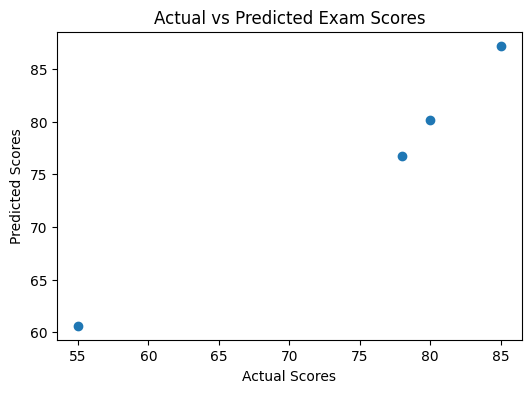

In [4]:

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_reg)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.show()


In [5]:

# Classification
df["status"] = np.where(df["Final_Exam_Score"] < 50, 0, 1)

X_clf = df.drop(["Final_Exam_Score", "status"], axis=1)
y_clf = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Accuracy: 1.0


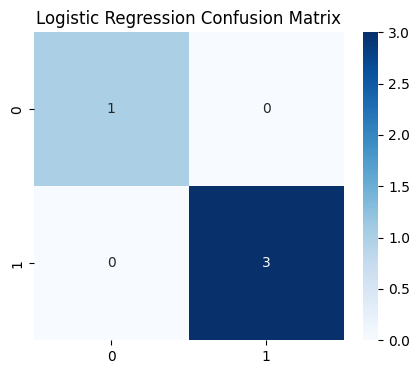

In [6]:

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [7]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Results")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Results
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

Accuracy: 0.75


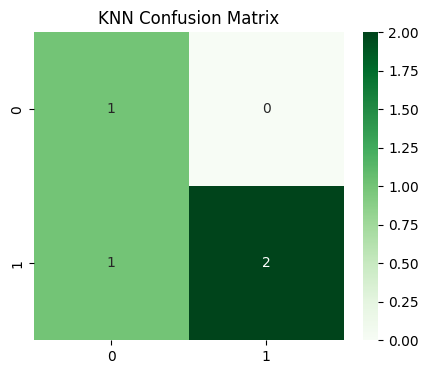

In [8]:

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.show()


In [9]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Results
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

Accuracy: 0.75


/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


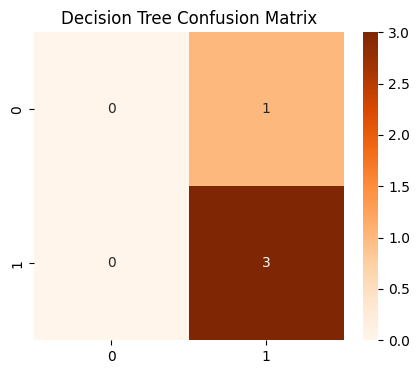

In [10]:

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.show()


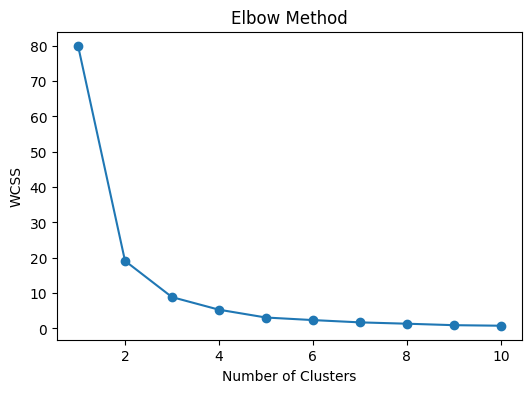

In [11]:

cluster_features = df[[
    "Hours_Studied",
    "Attendance (%)",
    "Assignments_Submitted",
    "Participation_Score"
]]

cluster_scaled = scaler.fit_transform(cluster_features)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [12]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

print("Cluster Distribution")
print(df["cluster"].value_counts())


Cluster Distribution
cluster
0    8
2    6
1    6
Name: count, dtype: int64


In [13]:

def recommend(row):
    if row["status"] == 0 and row["Attendance (%)"] < 60:
        return "Counseling + Attendance Monitoring"
    elif row["status"] == 0:
        return "Extra Tutoring"
    elif row["cluster"] == 2:
        return "Advanced Workshops"
    else:
        return "Regular Monitoring"

df["recommendation"] = df.apply(recommend, axis=1)

print("Sample Recommendations")
print(df[["Final_Exam_Score", "status", "cluster", "recommendation"]].head())


Sample Recommendations
   Final_Exam_Score  status  cluster                      recommendation
0                78       1        0                  Regular Monitoring
1                55       1        2                  Advanced Workshops
2                88       1        0                  Regular Monitoring
3                45       0        1  Counseling + Attendance Monitoring
4                70       1        2                  Advanced Workshops
